<a href="https://colab.research.google.com/github/Pandabear-67/Collision-tracker/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
labels = pd.read_csv("/content/drive/MyDrive/accident_files/sim_dataset/labels.csv")
labels

,rgb_path,annotations_path,type,accident_time,accident_frame,center_x,center_y,x1,y1,x2,y2,map,weather,camera_position,no_frames,duration,height,width,annotations_start_offset
0,videos/sideswipe/Town05_sideswipe_rain_44.mp4,video_annotations/Town05_sideswipe_rain_44.jso...,sideswipe,9.55,191,0.549219,0.387037,0.514583,0.350000,0.583854,0.424074,Town05,rain,44,391,19.55,1080,1920,31
1,videos/sideswipe/Town05_sideswipe_clear_00.mp4,video_annotations/Town05_sideswipe_clear_00.js...,sideswipe,8.65,173,0.494010,0.679167,0.453125,0.595370,0.534896,0.762963,Town05,clear,0,416,20.80,1080,1920,50
2,videos/sideswipe/Town05_sideswipe_sunset_03.mp4,video_annotations/Town05_sideswipe_sunset_03.j...,sideswipe,10.00,200,0.569531,0.890278,0.474479,0.781481,0.664583,0.999074,Town05,sunset,3,407,20.35,1080,1920,40
3,videos/sideswipe/Town05_sideswipe_night_30.mp4,video_annotations/Town05_sideswipe_night_30.js...,sideswipe,7.75,155,0.427604,0.600000,0.393229,0.551852,0.461979,0.648148,Town05,night,30,488,24.40,1080,1920,68
4,videos/sideswipe/Town05_sideswipe_clear_26.mp4,video_annotations/Town05_sideswipe_clear_26.js...,sideswipe,9.40,188,0.579948,0.261111,0.541146,0.195370,0.618750,0.326852,Town05,clear,26,468,23.40,1080,1920,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2206,videos/sideswipe/Town06_sideswipe_sunset_39.mp4,video_annotations/Town06_sideswipe_sunset_39.j...,sideswipe,11.35,227,0.513281,0.625463,0.482292,0.593519,0.544271,0.657407,Town06,sunset,39,290,14.50,1080,1920,147
2207,videos/sideswipe/Town06_sideswipe_sunset_40.mp4,video_annotations/Town06_sideswipe_sunset_40.j...,sideswipe,13.85,277,0.703125,0.552778,0.676042,0.524074,0.730208,0.581481,Town06,sunset,40,345,17.25,1080,1920,96
2208,videos/sideswipe/Town06_sideswipe_clear_00.mp4,video_annotations/Town06_sideswipe_clear_00.js...,sideswipe,15.70,314,0.348438,0.308796,0.328646,0.267593,0.368229,0.350000,Town06,clear,0,385,19.25,1080,1920,60
2209,videos/sideswipe/Town06_sideswipe_sunset_06.mp4,video_annotations/Town06_sideswipe_sunset_06.j...,sideswipe,10.85,217,0.482812,0.924537,0.453125,0.850000,0.512500,0.999074,Town06,sunset,6,265,13.25,1080,1920,159


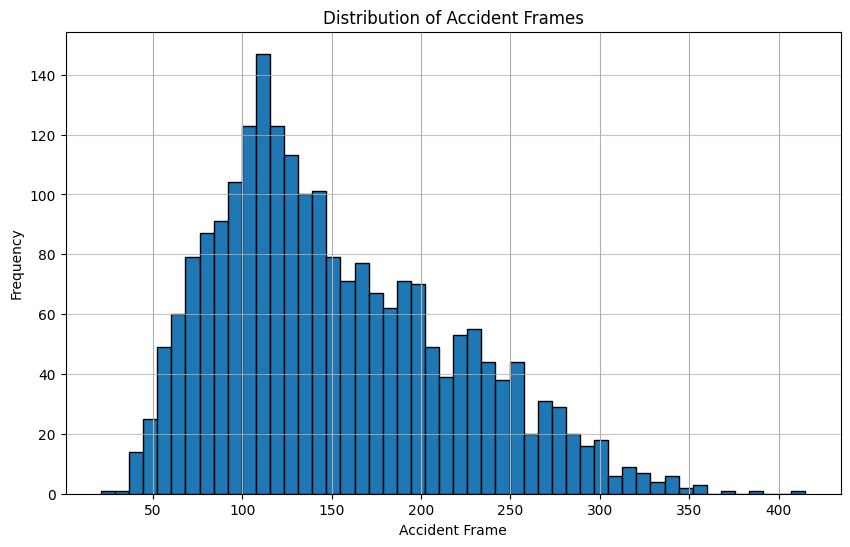

In [ ]:
#Plotting a graph of when the accident_frame occurs

#Thoughts (Normal distribution for the frames, not concentrated at a particular time)

plt.figure(figsize=(10, 6))
labels['accident_frame'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Accident Frames')
plt.xlabel('Accident Frame')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

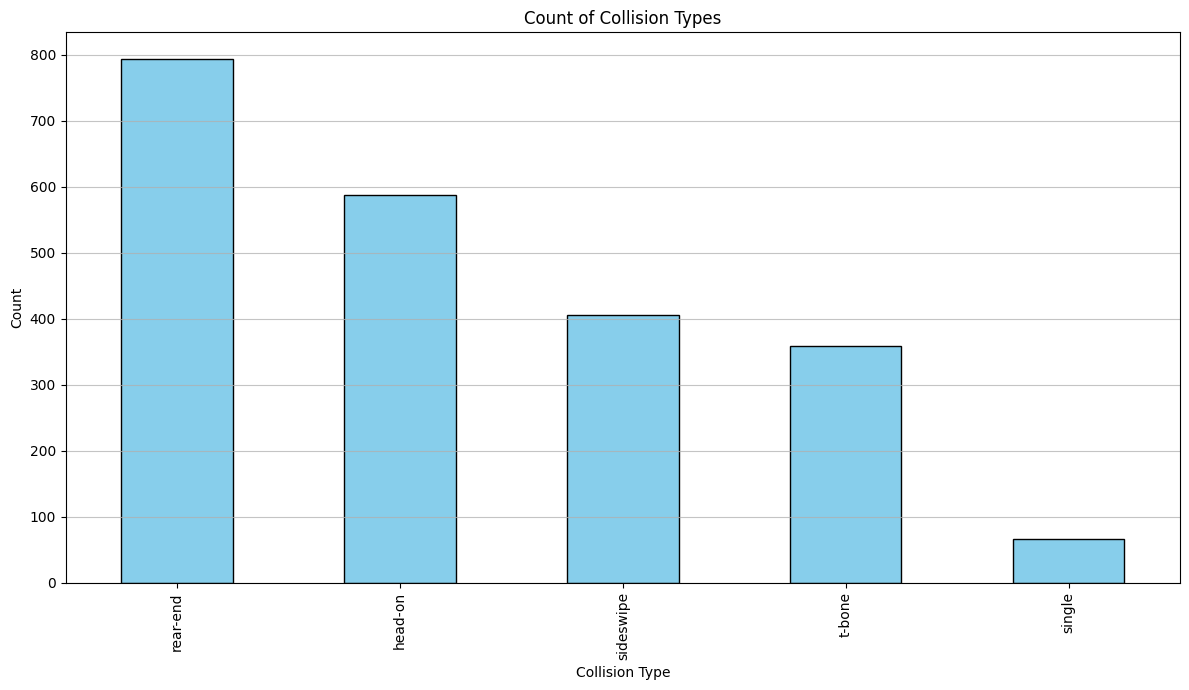

In [ ]:
#Need to oversample single type collisions

collision_counts = labels['type'].value_counts()

plt.figure(figsize=(12, 7))
collision_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Count of Collision Types')
plt.xlabel('Collision Type')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

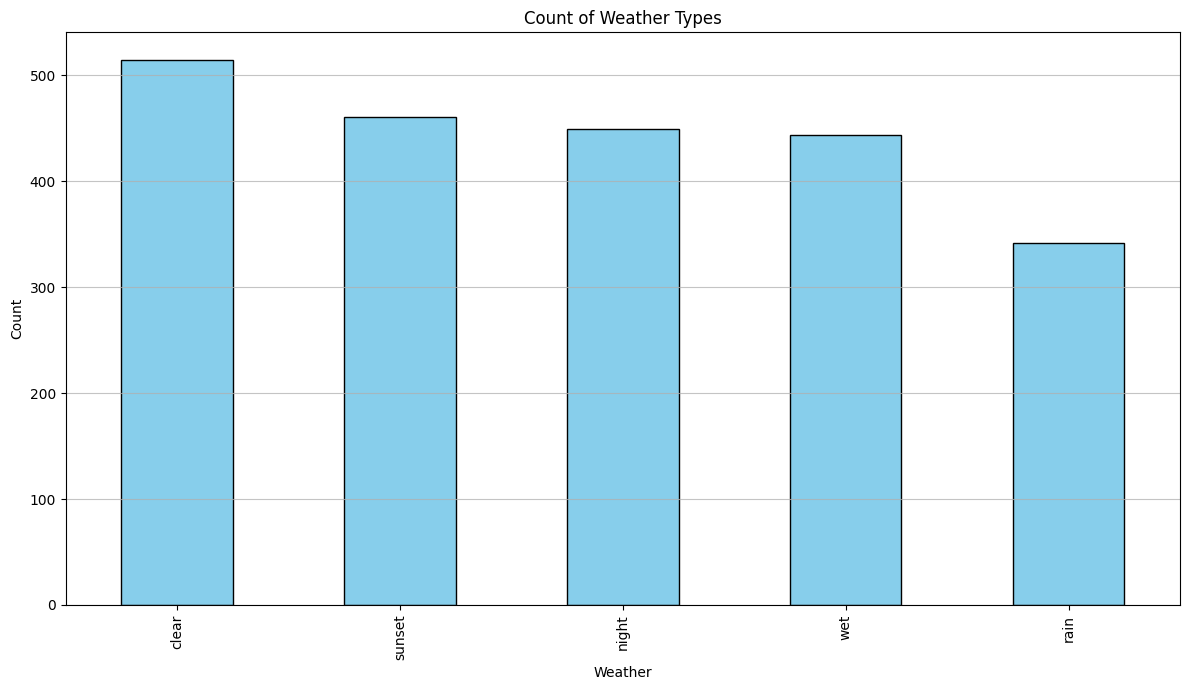

In [ ]:
#Count weather for each collision

weather_counts = labels['weather'].value_counts()

plt.figure(figsize=(12, 7))
weather_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Count of Weather Types')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

<Axes: xlabel='type', ylabel='weather'>

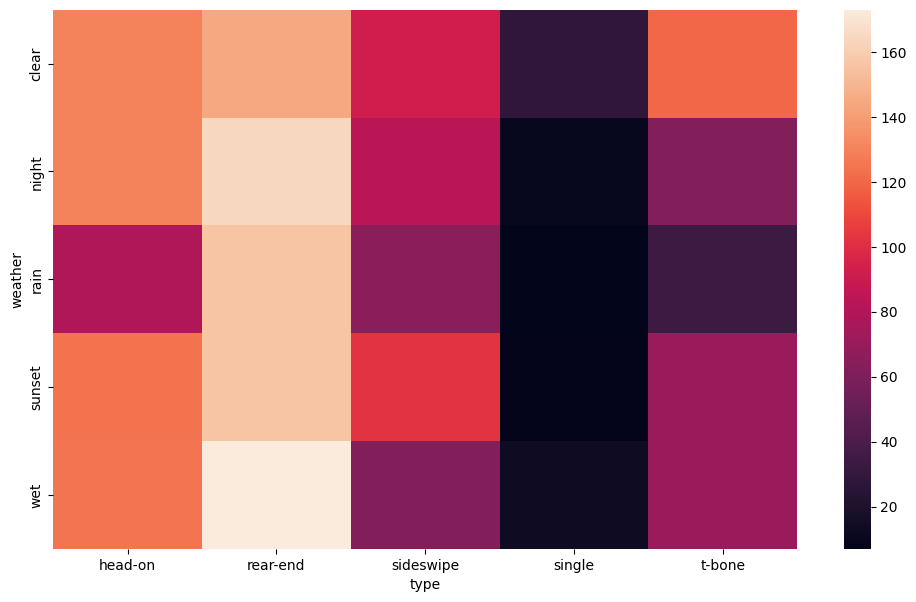

In [ ]:
weather_vs_type = pd.crosstab(labels['weather'], labels['type'])

plt.figure(figsize=(12, 7))
sns.heatmap(weather_vs_type)